# INITIALIZE NEURAL NETWORK

In [450]:
import torch
import torch.nn as nn
import numpy as np
import random

# ====================================================
# GLOBAL MODEL INITIALIZATION (STATIC)
# ====================================================
# Setting seeds for absolute reproducibility
SEED = 42893
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

class DQN(nn.Module):
    def __init__(self, state_size, action_size, hidden_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x1 = self.fc1(x)
        h1 = torch.relu(x1)
        x2 = self.fc2(h1)
        h2 = torch.relu(x2)
        q = self.fc3(h2)
        return q, h1, h2, x1, x2

# Shared instance used across the whole notebook
STATE_SIZE = 9
ACTION_SIZE = 3
HIDDEN_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize once
if 'shared_model' not in globals():
    shared_model = DQN(STATE_SIZE, ACTION_SIZE, HIDDEN_SIZE).to(device)
    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
    shared_model.apply(init_weights)
    print("✓ Global Static Model Initialized.")
else:
    print("✓ Using existing Global Static Model.")

✓ Using existing Global Static Model.


# CODE A: Feed Forward

In [451]:
# ====================================================
# DQN FORWARD PASS - With Model Loading Support (DETAILED)
# ====================================================

# @title Feed Forward
import numpy as np
import torch
import torch.nn as nn
import random
import os

# ==================== CONFIGURATION ====================
LOAD_MODEL = True  # Set to True to load best-model.pth, False to use random weights
MODEL_PATH = "best-model.pth"

# ==================== INPUTS ====================
Angle = 3  # 1=90° Left, 2=45° Left, 3=0° (Forward), 4=45° Right, 5=90° Right
Sensor1 = 1.0
Sensor2 = 1.0
Sensor3 = 0.76
Sensor4 = 0.70
Sensor5 = 0.76
Sensor6 = 1.0
Sensor7 = 1.0
Prev_action = 1  # 0=No Action, 1=Forward, 2=Turn Left, 3=Turn Right

# ==================== CONSTANTS ====================
STATE_SIZE = 9
ACTION_SIZE = 3
HIDDEN_SIZE = 64

# ==================== DEFINE DQN MODEL ====================
class DQN(nn.Module):
    def __init__(self, state_size, action_size, hidden_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x1 = self.fc1(x)
        h1 = torch.relu(x1)
        x2 = self.fc2(h1)
        h2 = torch.relu(x2)
        q = self.fc3(h2)
        return q, h1, h2, x1, x2

# ==================== BUILD INPUT VECTOR ====================
state = np.array([float(Angle), Sensor1, Sensor2, Sensor3, Sensor4,
                  Sensor5, Sensor6, Sensor7, float(Prev_action)], dtype=np.float32)

action_names = ["Forward", "Turn Left", "Turn Right"]
prev_action_names = ["None", "Forward", "Turn Left", "Turn Right"]

print("=" * 80)
print("DQN FORWARD PASS - DETAILED CALCULATION")
print("=" * 80)

# ==================== LOAD MODEL ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DQN(STATE_SIZE, ACTION_SIZE, HIDDEN_SIZE).to(device)

model_loaded = False
if LOAD_MODEL and os.path.exists(MODEL_PATH):
    try:
        state_dict = torch.load(MODEL_PATH, map_location=device)
        model.load_state_dict(state_dict)
        model.eval()
        model_loaded = True
        print(f"✓ Model loaded successfully from: {os.path.abspath(MODEL_PATH)}")
    except Exception as e:
        print(f"⚠ Failed to load model: {e}")
        print("Using randomly initialized weights instead.")
else:
    if LOAD_MODEL:
        print(f"⚠ Model file not found: {MODEL_PATH}")
        print("Using randomly initialized weights instead.")
    else:
        print("LOAD_MODEL = False, using randomly initialized weights.")

    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
    model.apply(init_weights)
    model.eval()

print(f"Using device: {device}")

# ==================== A) AGENT INPUTS ====================
print("\n" + "=" * 80)
print("A) AGENT INPUTS")
print("=" * 80)
print(f"{'Input':<15} {'Value':<15} {'Normalized':<15}")
print("-" * 45)
angle_display = "0°" if Angle == 3 else f"{int((Angle-3)*45)}°"
print(f"{'Angle':<15} {angle_display:<15} {Angle:<15.2f}")
print(f"{'Sensor 1':<15} {'1.00':<15} {Sensor1:<15.2f}")
print(f"{'Sensor 2':<15} {'1.00':<15} {Sensor2:<15.2f}")
print(f"{'Sensor 3':<15} {'0.76':<15} {Sensor3:<15.2f}")
print(f"{'Sensor 4':<15} {'0.70':<15} {Sensor4:<15.2f}")
print(f"{'Sensor 5':<15} {'0.76':<15} {Sensor5:<15.2f}")
print(f"{'Sensor 6':<15} {'1.00':<15} {Sensor6:<15.2f}")
print(f"{'Sensor 7':<15} {'1.00':<15} {Sensor7:<15.2f}")
print(f"{'Prev Action':<15} {prev_action_names[Prev_action]:<15} {Prev_action:<15.2f}")

print(f"\nState Vector: {state.tolist()}")

# ==================== B) NETWORK ARCHITECTURE ====================
print("\n" + "=" * 80)
print("B) NETWORK ARCHITECTURE")
print("=" * 80)
print("Model Structure: 9 → 64 → 64 → 3")
print("\nTotal weights:")
print(f"  9 × 64  = 576")
print(f"  64 × 64 = 4096")
print(f"  64 × 3  = 192")
print(f"  {576} + {4096} + {192} = 4864 weights")

print("\nExample weight matrix:")
print("Layer 1 (9→64):")
print("[ w1,1   w1,2   ...  w1,9 ] -> h1,1")
print("[ w2,1   w2,2   ...  w2,9 ] -> h1,2")
print("...")
print("[ w64,1  w64,2  ...  w64,9 ] -> h1,64")
print("\nLayer 2 (64→64):")
print("[ w1,1   w1,2   ...  w1,64 ] -> h2,1")
print("[ w2,1   w2,2   ...  w2,64 ] -> h2,2")
print("...")
print("[ w64,1  w64,2  ...  w64,64 ] -> h2,64")
print("\nOutput Layer (64→3):")
print("[ w1,1  w1,2  ...  w1,64 ] -> Q0 Forward")
print("[ w2,1  w2,2  ...  w2,64 ] -> Q1 Turn Left")
print("[ w3,1  w3,2  ...  w3,64 ] -> Q2 Turn Right")

# ==================== C) FORWARD PASS ====================
print("\n" + "=" * 80)
print("C) FORWARD PASS CALCULATION")
print("=" * 80)

# Convert input to tensor
input_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

with torch.no_grad():
    q_values, h1, h2, z1, z2 = model(input_tensor)

    # Convert to numpy
    q_np = q_values.cpu().numpy().flatten()
    h1_np = h1.cpu().numpy().flatten()
    h2_np = h2.cpu().numpy().flatten()
    z1_np = z1.cpu().numpy().flatten()
    z2_np = z2.cpu().numpy().flatten()

    # Get weights and biases
    w1 = model.fc1.weight.cpu().numpy()
    b1 = model.fc1.bias.cpu().numpy()
    w2 = model.fc2.weight.cpu().numpy()
    b2 = model.fc2.bias.cpu().numpy()
    w3 = model.fc3.weight.cpu().numpy()
    b3 = model.fc3.bias.cpu().numpy()

print("\n" + "=" * 80)
print("LAYER 1: 9 → 64 (Input to Hidden Layer 1)")
print("=" * 80)

print("\nFormula:")
print("z1_j = b1_j + Σ(i=1 to 9) W1[j,i] * x_i")
print("h1_j = ReLU(z1_j)")
print("")
print("Keterangan:")
print("  j = 1,...,64 untuk Hidden Layer 1")
print("  x_i = input ke-i (i=1,...,9)")
print("  ReLU: jika z < 0 → 0, jika z ≥ 0 → z")

print("\nInput vector x =", state.tolist())

# Show first 5 neurons calculation with detail
print("\nSample calculation for first 5 neurons:")
print("-" * 80)
print(f"{'Neuron':<10} {'Formula':<50} {'z (before ReLU)':<20} {'h (after ReLU)':<20}")
print("-" * 80)

for j in range(min(5, HIDDEN_SIZE)):
    # Build formula string
    terms = []
    for i in range(STATE_SIZE):
        if abs(w1[j, i]) > 0.001:
            sign = "+" if w1[j, i] >= 0 else ""
            terms.append(f"{sign}{w1[j, i]:.4f}*{state[i]:.2f}")

    formula = f"{b1[j]:.4f} + " + " + ".join(terms[:3])
    if len(terms) > 3:
        formula += " + ..."

    z_val = z1_np[j]
    h_val = h1_np[j]
    print(f"h1[{j}]   {formula:<50} {z_val:<20.6f} {h_val:<20.6f}")

# Show non-zero activations
active_count = np.sum(h1_np > 0)
print(f"\nNon-zero activations in Layer 1: {active_count} out of {HIDDEN_SIZE}")
print(f"Activation rate: {active_count/HIDDEN_SIZE*100:.1f}%")

print("\n" + "=" * 80)
print("LAYER 2: 64 → 64 (Hidden Layer 1 to Hidden Layer 2)")
print("=" * 80)

print("\nFormula:")
print("z2_j = b2_j + Σ(i=1 to 64) W2[j,i] * h1_i")
print("h2_j = ReLU(z2_j)")
print("")
print("Keterangan:")
print("  j = 1,...,64 untuk Hidden Layer 2")
print("  h1_i = output dari hidden layer 1 ke-i (i=1,...,64)")

# Show first 5 neurons calculation
print("\nSample calculation for first 5 neurons:")
print("-" * 80)
print(f"{'Neuron':<10} {'z (before ReLU)':<20} {'h (after ReLU)':<20}")
print("-" * 80)

for j in range(min(5, HIDDEN_SIZE)):
    z_val = z2_np[j]
    h_val = h2_np[j]
    print(f"h2[{j}]   {z_val:<20.6f} {h_val:<20.6f}")

active_count2 = np.sum(h2_np > 0)
print(f"\nNon-zero activations in Layer 2: {active_count2} out of {HIDDEN_SIZE}")
print(f"Activation rate: {active_count2/HIDDEN_SIZE*100:.1f}%")

# ==================== D) ACTIVE NEURONS IN HIDDEN LAYER 2 ====================
print("\n" + "=" * 80)
print("D) ACTIVE NEURONS IN HIDDEN LAYER 2 (h2 > 0)")
print("=" * 80)

active_indices = np.where(h2_np > 0)[0]
print(f"Total active neurons: {len(active_indices)}")
print("\nActive neurons (index: value):")
print("-" * 50)

for idx in active_indices[:20]:
    print(f"h2[{idx:2d}] = {h2_np[idx]:.8f}")

if len(active_indices) > 20:
    print(f"... and {len(active_indices) - 20} more active neurons")

# ==================== E) OUTPUT LAYER CALCULATION ====================
print("\n" + "=" * 80)
print("E) OUTPUT LAYER: 64 → 3 (Q-Values)")
print("=" * 80)

print("\nFormula:")
print("Q_j = b3_j + Σ(i=1 to 64) W3[j,i] * h2_i")
print("")
print("Keterangan:")
print("  Q_j : Nilai Q-value untuk aksi ke-j")
print("  b3_j : Bias pada neuron output ke-j")
print("  W3[j,i] : Weight menghubungkan neuron i ke output j")
print("  h2_i : Aktivasi neuron i pada hidden layer 2")
print("  j = 0 (Forward), 1 (Turn Left), 2 (Turn Right)")

print("\nDetailed calculation for each Q-value:")
print("-" * 80)

# Store Q-value components for display
q_components = []

for j in range(ACTION_SIZE):
    print(f"\nQ_{j} ({action_names[j]}):")
    print(f"  Q_{j} = {b3[j]:.6f} + Σ W3[{j},i] * h2_i")

    # Show significant terms (where h2_i > 0)
    terms = []
    active_terms = []
    for i in range(HIDDEN_SIZE):
        if h2_np[i] > 0:
            term = w3[j, i] * h2_np[i]
            if abs(term) > 0.001:
                active_terms.append((i, term, w3[j, i], h2_np[i]))
                terms.append(f"({w3[j, i]:.4f})({h2_np[i]:.4f})={term:.4f}")

    if terms:
        print(f"  Significant terms:")
        for idx, (i, term, weight, activation) in enumerate(active_terms[:10]):
            print(f"    i={i:2d}: ({weight:.4f})({activation:.4f}) = {term:.6f}")
        if len(active_terms) > 10:
            print(f"    ... and {len(active_terms) - 10} more terms")

    sum_terms = sum([term for _, term, _, _ in active_terms])
    print(f"\n  Sum of W3 * h2 = {sum_terms:.6f}")
    print(f"  Bias = {b3[j]:.6f}")
    print(f"  Q_{j} = {b3[j]:.6f} + {sum_terms:.6f} = {q_np[j]:.8f}")

    q_components.append({
        'bias': b3[j],
        'sum_terms': sum_terms,
        'total': q_np[j]
    })

# ==================== F) Q-VALUE OUTPUT SUMMARY ====================
print("\n" + "=" * 80)
print("F) Q-VALUE OUTPUT SUMMARY")
print("=" * 80)

print(f"\n{'Output':<12} {'Aksi':<15} {'Q-Value':<15} {'Bias':<15} {'Σ W*h2':<15}")
print("-" * 72)
for i, name in enumerate(action_names):
    print(f"{f'Q{i}':<12} {name:<15} {q_np[i]:<15.2f} {q_components[i]['bias']:<15.4f} {q_components[i]['sum_terms']:<15.4f}")

# Best action
best_action = int(np.argmax(q_np))
print(f"\nBest Action: {best_action} ({action_names[best_action]})")
print(f"Best Q-Value: {q_np[best_action]:.2f}")

# Sort Q-values
sorted_indices = np.argsort(q_np)[::-1]
print(f"\nQ-Value Ranking (highest to lowest):")
for i, idx in enumerate(sorted_indices):
    print(f"  {i+1}. {action_names[idx]}: {q_np[idx]:.2f}")

# ==================== G) SIMULATE RANDOM ACTION ====================
print("\n" + "=" * 80)
print("G) SIMULATE RANDOM ACTION (Exploration)")
print("=" * 80)

random_action = random.randint(0, 2)
print(f"Random Action Selected: {random_action} ({action_names[random_action]})")

# Simulate next state
next_state = state.copy()
next_state[8] = float(random_action)

# Simulate reward
if random_action == best_action:
    reward = 1.0
    print(f"Reward: +1.00 (Random action matches best action!)")
else:
    reward = -0.5
    print(f"Reward: -0.50 (Random action does NOT match best action)")

done = 0  # Episode continues

# ==================== H) STORED BUFFER DATA ====================
print("\n" + "=" * 80)
print("H) STORED REPLAY BUFFER DATA")
print("=" * 80)

replay_buffer_entry = [state.tolist(), random_action, reward, next_state.tolist(), done]

print("Stored Replay Buffer:")
print(f"s_t      : {state.tolist()} (state step 1)")
print(f"a_(t)    : {random_action} (action step 1 - {action_names[random_action]})")
print(f"r_(t)    : {reward:.2f} (reward step 1)")
print(f"s_(t+1)  : {next_state.tolist()} (state step 2)")
print(f"d_t      : {done} (episode belum berakhir)")

print("\nBuffer Entry (Array Format):")
print(replay_buffer_entry)

# ==================== I) MODEL INFO ====================
print("\n" + "=" * 80)
print("I) MODEL INFORMATION")
print("=" * 80)
print(f"Model Loaded: {model_loaded}")
print(f"Model Path: {MODEL_PATH if model_loaded else 'Not loaded'}")
print(f"LOAD_MODEL Flag: {LOAD_MODEL}")

# Network parameter stats
print("\nNetwork Parameter Statistics:")
print("-" * 50)
print(f"Layer 1 (9→64):")
print(f"  Weights shape: {w1.shape}")
print(f"  Weight stats: min={w1.min():.6f}, max={w1.max():.6f}, mean={w1.mean():.6f}")
print(f"  Bias stats: min={b1.min():.6f}, max={b1.max():.6f}, mean={b1.mean():.6f}")

print(f"\nLayer 2 (64→64):")
print(f"  Weights shape: {w2.shape}")
print(f"  Weight stats: min={w2.min():.6f}, max={w2.max():.6f}, mean={w2.mean():.6f}")
print(f"  Bias stats: min={b2.min():.6f}, max={b2.max():.6f}, mean={b2.mean():.6f}")

print(f"\nLayer 3 (64→3):")
print(f"  Weights shape: {w3.shape}")
print(f"  Weight stats: min={w3.min():.6f}, max={w3.max():.6f}, mean={w3.mean():.6f}")
print(f"  Bias stats: min={b3.min():.6f}, max={b3.max():.6f}, mean={b3.mean():.6f}")

# ==================== J) SUMMARY TABLE ====================
print("\n" + "=" * 80)
print("J) SUMMARY TABLE")
print("=" * 80)

print(f"\n{'Input':<15} {'Value':<15} {'Normalized':<15}")
print("-" * 45)
angle_display = "0°" if Angle == 3 else f"{int((Angle-3)*45)}°"
print(f"{'Angle':<15} {angle_display:<15} {Angle:<15.2f}")
print(f"{'Sensor 1':<15} {'1.00':<15} {Sensor1:<15.2f}")
print(f"{'Sensor 2':<15} {'1.00':<15} {Sensor2:<15.2f}")
print(f"{'Sensor 3':<15} {'0.76':<15} {Sensor3:<15.2f}")
print(f"{'Sensor 4':<15} {'0.70':<15} {Sensor4:<15.2f}")
print(f"{'Sensor 5':<15} {'0.76':<15} {Sensor5:<15.2f}")
print(f"{'Sensor 6':<15} {'1.00':<15} {Sensor6:<15.2f}")
print(f"{'Sensor 7':<15} {'1.00':<15} {Sensor7:<15.2f}")
print(f"{'Prev Action':<15} {prev_action_names[Prev_action]:<15} {Prev_action:<15.2f}")

print(f"\n{'Output':<12} {'Aksi':<15} {'Q-Value':<15} {'Status':<15}")
print("-" * 57)
for i, name in enumerate(action_names):
    status = "✓ BEST" if i == best_action else ""
    print(f"{f'Q{i}':<12} {name:<15} {q_np[i]:<15.2f} {status:<15}")

print("\n" + "=" * 80)
print("✓ FORWARD PASS COMPLETE")
print("=" * 80)

DQN FORWARD PASS - DETAILED CALCULATION
✓ Model loaded successfully from: /content/best-model.pth
Using device: cpu

A) AGENT INPUTS
Input           Value           Normalized     
---------------------------------------------
Angle           0°              3.00           
Sensor 1        1.00            1.00           
Sensor 2        1.00            1.00           
Sensor 3        0.76            0.76           
Sensor 4        0.70            0.70           
Sensor 5        0.76            0.76           
Sensor 6        1.00            1.00           
Sensor 7        1.00            1.00           
Prev Action     Forward         1.00           

State Vector: [3.0, 1.0, 1.0, 0.7599999904632568, 0.699999988079071, 0.7599999904632568, 1.0, 1.0, 1.0]

B) NETWORK ARCHITECTURE
Model Structure: 9 → 64 → 64 → 3

Total weights:
  9 × 64  = 576
  64 × 64 = 4096
  64 × 3  = 192
  576 + 4096 + 192 = 4864 weights

Example weight matrix:
Layer 1 (9→64):
[ w1,1   w1,2   ...  w1,9 ] -> h1,1
[ w

# CODE B: Q-TRAINING

In [452]:
# @title Q-TRAINING 1/4: Sampling Mini-Batch
import random
import json

# ==================== KONFIGURASI ====================
BATCH_SIZE = 64
GENERATE_RANDOM = False  # True = generate random, False = gunakan REPLAY_BUFFER

# ==================== REPLAY BUFFER (jika GENERATE_RANDOM = False) ====================
# Format: [Angle, Sensor 1-7, Previous Action]
COMMON_STATE1 = [3.00, 0.33, 0.47, 0.87, 1.00, 0.87, 0.47, 0.33, 0.00] # STATE SEBELUM ACTION
COMMON_STATE2 = [3.00, 0.33, 0.47, 0.87, 1.00, 0.87, 0.47, 0.33, 0.00] # STATE SEBELUM ACTION
COMMON_NEXT_STATE1 = [3.0, 1.0, 0.52, 0.40, 0.37, 0.40, 0.52, 1.0, 1.0] # NEXT STATE APABILA ACTION "FORWARD"
COMMON_NEXT_STATE2 = [4.0, 0.47, 1.00, 0.87, 0.47, 0.36, 0.33, 0.47, 3.0] # NEXT STATE APABILA ACTION "TURN RIGHT"

REPLAY_BUFFER = [
 # Format: [state, action, reward, next_state, done]


    # ========== ACTION 2 (TURN RIGHT) - 25 samples, reward +0 ==========
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],
    [COMMON_STATE2, 2, 0.00, COMMON_NEXT_STATE2, 0],

     # ========== ACTION 0 (TURN FORWARD) - 40 samples, reward +2 ==========
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
    [COMMON_STATE1, 0, 2.00, COMMON_NEXT_STATE1, 0],
]
# ==================== FUNGSI GENERATE RANDOM ====================
def generate_random_replay_buffer(size=64):
    """Generate random replay buffer"""
    replay_buffer = []
    for _ in range(size):
        angle = random.randint(1, 5)
        sensors = [round(random.uniform(0.0, 1.0), 2) for _ in range(7)]
        prev_action = random.randint(0, 3)
        state = [float(angle)] + sensors + [float(prev_action)]

        action = random.randint(0, 2)
        reward = round(random.uniform(-2.0, 1.5), 2)

        next_angle = random.randint(1, 5)
        next_sensors = [round(random.uniform(0.0, 1.0), 2) for _ in range(7)]
        next_prev_action = action
        next_state = [float(next_angle)] + next_sensors + [float(next_prev_action)]

        done = 1 if random.random() < 0.1 else 0
        replay_buffer.append([state, action, reward, next_state, done])
    return replay_buffer

# ==================== SAMPLE PERTAMA (JSON) ====================
SAMPLE_PERTAMA = {
    "state": COMMON_STATE1,
    "action": 0,
    "reward": -0.98,
    "next_state": COMMON_NEXT_STATE1,
    "done": 0
}

# ==================== MAIN ====================
print("=" * 80)
print("KODE 1: SAMPLING MINI-BATCH")
print("=" * 80)

# Generate atau gunakan replay buffer
if GENERATE_RANDOM:
    print(f"\nMode: GENERATE_RANDOM = True")
    print(f"Generate {BATCH_SIZE} data random...")
    replay_buffer = generate_random_replay_buffer(BATCH_SIZE)
else:
    print(f"\nMode: GENERATE_RANDOM = False")
    print(f"Menggunakan REPLAY_BUFFER dengan {len(REPLAY_BUFFER)} data...")
    replay_buffer = REPLAY_BUFFER.copy()
    # Jika buffer kurang dari BATCH_SIZE, tambahkan random
    while len(replay_buffer) < BATCH_SIZE:
        angle = random.randint(1, 5)
        sensors = [round(random.uniform(0.0, 1.0), 2) for _ in range(7)]
        prev_action = random.randint(0, 3)
        state = [float(angle)] + sensors + [float(prev_action)]
        action = random.randint(0, 2)
        reward = round(random.uniform(-2.0, 1.5), 2)
        next_angle = random.randint(1, 5)
        next_sensors = [round(random.uniform(0.0, 1.0), 2) for _ in range(7)]
        next_prev_action = action
        next_state = [float(next_angle)] + next_sensors + [float(next_prev_action)]
        done = 1 if random.random() < 0.1 else 0
        replay_buffer.append([state, action, reward, next_state, done])

print(f"\nTotal data dalam replay buffer: {len(replay_buffer)}")
print(f"Batch Size: {BATCH_SIZE}")

# Sampling mini-batch
mini_batch = random.sample(replay_buffer, BATCH_SIZE)

# Tampilkan sample pertama yang terpilih
sample_pertama = mini_batch[0]
print("\n" + "=" * 80)
print("SAMPLE PERTAMA YANG TERPILIH:")
print("=" * 80)
print(f"s_t      : {sample_pertama[0]}")
print(f"a_(t)    : {sample_pertama[1]}")
print(f"r_(t)    : {sample_pertama[2]}")
print(f"s_(t+1)  : {sample_pertama[3]}")
print(f"d_t      : {sample_pertama[4]} (episode {'berakhir' if sample_pertama[4] == 1 else 'belum berakhir'})")

# Tampilkan 10 sample pertama
print("\n" + "=" * 80)
print("10 DATA PERTAMA DALAM MINI-BATCH:")
print("=" * 80)
print(f"{'No':<5} {'State':<50} {'Action':<8} {'Reward':<10} {'Done':<5}")
print("-" * 80)
for i, data in enumerate(mini_batch[:10], 1):
    state_str = str(data[0])[:45] + "..." if len(str(data[0])) > 45 else str(data[0])
    # data[0]=state, data[1]=action, data[2]=reward, data[3]=next_state, data[4]=done
    print(f"{i:<5} {state_str:<50} {data[1]:<8} {data[2]:<10.2f} {data[4]:<5}")

# Store hasil dalam variabel untuk kode selanjutnya
MINI_BATCH = mini_batch
BATCH_SIZE = BATCH_SIZE
SAMPLE_PERTAMA = mini_batch[0]

print("\n" + "=" * 80)
print("✓ Mini-batch berhasil di-store dalam variabel 'MINI_BATCH'")
print(f"✓ Total data: {len(MINI_BATCH)}")
print("=" * 80)

KODE 1: SAMPLING MINI-BATCH

Mode: GENERATE_RANDOM = False
Menggunakan REPLAY_BUFFER dengan 65 data...

Total data dalam replay buffer: 65
Batch Size: 64

SAMPLE PERTAMA YANG TERPILIH:
s_t      : [3.0, 0.33, 0.47, 0.87, 1.0, 0.87, 0.47, 0.33, 0.0]
a_(t)    : 0
r_(t)    : 2.0
s_(t+1)  : [3.0, 1.0, 0.52, 0.4, 0.37, 0.4, 0.52, 1.0, 1.0]
d_t      : 0 (episode belum berakhir)

10 DATA PERTAMA DALAM MINI-BATCH:
No    State                                              Action   Reward     Done 
--------------------------------------------------------------------------------
1     [3.0, 0.33, 0.47, 0.87, 1.0, 0.87, 0.47, 0.33...   0        2.00       0    
2     [3.0, 0.33, 0.47, 0.87, 1.0, 0.87, 0.47, 0.33...   0        2.00       0    
3     [3.0, 0.33, 0.47, 0.87, 1.0, 0.87, 0.47, 0.33...   0        2.00       0    
4     [3.0, 0.33, 0.47, 0.87, 1.0, 0.87, 0.47, 0.33...   2        0.00       0    
5     [3.0, 0.33, 0.47, 0.87, 1.0, 0.87, 0.47, 0.33...   2        0.00       0    
6     [3.0, 

In [453]:
import random
import math
# @title Q-TRAINING 2/4: Target Q-Value (FIXED SINKRONISASI)
# ==================== KONFIGURASI ====================
GAMMA = 0.99
MANUAL_CALCULATION = False

# ==================== FUNGSI ====================
def calculate_target(reward, done, max_q_next, gamma=GAMMA):
    return reward + (1 - done) * gamma * max_q_next

def get_q_values_from_model(state):
    """Simulasi forward pass untuk mendapatkan Q-values"""
    base = random.uniform(-0.2, 0.2)
    return [round(base + random.uniform(-0.1, 0.1), 4) for _ in range(3)]

# ==================== MAIN ====================
print("=" * 80)
print("KODE 2: TARGET Q-VALUE (FIXED)")
print("=" * 80)

try:
    mini_batch = MINI_BATCH
except NameError:
    print("⚠ ERROR: MINI_BATCH tidak ditemukan!")
    mini_batch = []

TARGET_VALUES = []
Q_PREDICTED_VALUES = []

if mini_batch:
    # 1. PRE-CALCULATE ALL DATA AGAR SINKRON
    # Kita hitung semua dulu dan simpan di list
    computed_data = []
    for item in mini_batch:
        s_i, a_i, r_i, ns_i, d_i = item
        q_curr = get_q_values_from_model(s_i)
        qp = q_curr[a_i]
        q_n = get_q_values_from_model(ns_i)
        mqn = max(q_n)
        ti = calculate_target(r_i, d_i, mqn)

        computed_data.append({
            'q_s_t': q_curr,
            'q_pred': qp,
            'q_ns': q_n,
            'max_q_next': mqn,
            'target': ti
        })
        TARGET_VALUES.append(ti)
        Q_PREDICTED_VALUES.append(qp)

    # 2. DISPLAY DETAIL MENGGUNAKAN DATA YANG SUDAH DISIMPAN (INDEX 0)
    d = computed_data[0]
    s, a, r, ns, done = mini_batch[0]

    print("\n" + "=" * 80)
    print("PERHITUNGAN DETAIL SAMPLE PERTAMA (SINKRON DENGAN TABEL)")
    print("=" * 80)
    print(f"s_t      : {s}")
    print(f"a_(t)    : {a}")
    print(f"r_(t)    : {r}")
    print(f"d_t      : {done}")

    print(f"\nA) Predicted Q-values untuk s_t:")
    print(f"   Q(s_t) = {d['q_s_t']}")
    print(f"   Q(s_t, a_t) = {d['q_pred']:.4f} (Aksi {a})")

    print(f"\nB) Predicted Q-values untuk s_(t+1):")
    print(f"   Q(s_(t+1)) = {d['q_ns']}")
    print(f"   max Q(s_(t+1)) = {d['max_q_next']:.4f}")

    print(f"\nC) Target Calculation (y_i):")
    print(f"   y_i = r_t + (1-d_t) * ̲ * max Q(s_t+1)")
    print(f"   y_i = {r} + (1-{done}) * {GAMMA} * {d['max_q_next']:.4f}")
    print(f"   y_i = {d['target']:.4f}")

    # 3. TAMPILKAN TABEL
    print("\n" + "-" * 110)
    print(f"{'Sampel':<8} {'Action':<8} {'Reward':<10} {'Q(s_t, a_t)':<15} {'Target (y_i)':<15}")
    print("-" * 110)

    for idx, (item, comp) in enumerate(zip(mini_batch, computed_data)):
        if idx < 10:
            print(f"{idx+1:<8} {item[1]:<8} {item[2]:<10.2f} {comp['q_pred']:<15.4f} {comp['target']:<15.4f}")

    print("...")
    SAMPLE_TARGET = TARGET_VALUES[0]
    SAMPLE_Q_PRED = Q_PREDICTED_VALUES[0]

print("\n" + "=" * 80)
print("✓ TARGET_VALUES & Q_PREDICTED_VALUES sekarang sinkron antara Detail dan Tabel.")
print("=" * 80)

KODE 2: TARGET Q-VALUE (FIXED)

PERHITUNGAN DETAIL SAMPLE PERTAMA (SINKRON DENGAN TABEL)
s_t      : [3.0, 0.33, 0.47, 0.87, 1.0, 0.87, 0.47, 0.33, 0.0]
a_(t)    : 0
r_(t)    : 2.0
d_t      : 0

A) Predicted Q-values untuk s_t:
   Q(s_t) = [-0.0037, -0.0216, -0.0573]
   Q(s_t, a_t) = -0.0037 (Aksi 0)

B) Predicted Q-values untuk s_(t+1):
   Q(s_(t+1)) = [0.2461, 0.1763, 0.2506]
   max Q(s_(t+1)) = 0.2506

C) Target Calculation (y_i):
   y_i = r_t + (1-d_t) * ̲ * max Q(s_t+1)
   y_i = 2.0 + (1-0) * 0.99 * 0.2506
   y_i = 2.2481

--------------------------------------------------------------------------------------------------------------
Sampel   Action   Reward     Q(s_t, a_t)     Target (y_i)   
--------------------------------------------------------------------------------------------------------------
1        0        2.00       -0.0037         2.2481         
2        0        2.00       -0.1494         2.0928         
3        0        2.00       0.0918          2.1424         
4

In [454]:
import random
# @title Q-TRAINING 3/4: TD ERROR
# ==================== MAIN ====================
print("=" * 80)
print("KODE 3: TD ERROR (TEMPORAL DIFFERENCE)")
print("=" * 80)

try:
    # Menarik data langsung dari KODE 2/4
    target_vals = TARGET_VALUES
    q_pred_vals = Q_PREDICTED_VALUES

    if len(target_vals) == 0 or len(q_pred_vals) == 0:
        raise ValueError("Data kosong!")
except (NameError, ValueError):
    print("\n⚠ ERROR: Jalankan KODE 2 terlebih dahulu untuk mendapatkan target dan prediksi!")
    target_vals, q_pred_vals = [], []

if target_vals and q_pred_vals:
    TD_ERRORS = []

    # Display calculation detail for the first sample (Sample #1 dari Batch)
    print("\n" + "=" * 80)
    print("PERHITUNGAN DETAIL TD ERROR (SAMPLE 1 DARI MINI-BATCH)")
    print("=" * 80)

    y_i = target_vals[0]
    q_sa = q_pred_vals[0]
    td_sample = y_i - q_sa

    print(f"1. Target Q-Value (y_i)      : {y_i:.4f} (Dari Target Network/Bellman)")
    print(f"2. Predicted Q-Value Q(s,a)   : {q_sa:.4f} (Dari Policy Network)")
    print(f"\nRumus TD Error:")
    print(f"   δ = y_i - Q(s_t, a_t)")
    print(f"   δ = {y_i:.4f} - {q_sa:.4f}")
    print(f"   δ = {td_sample:.4f}")

    if td_sample > 0:
        print("\nInterpretasi: Prediksi terlalu RENDAH (Underestimate).")
        print("              Target lebih besar dari prediksi saat ini.")
    else:
        print("\nInterpretasi: Prediksi terlalu TINGGI (Overestimate).")
        print("              Target lebih kecil dari prediksi saat ini.")

    # Generate full list and summary table for the batch
    print("\n" + "-" * 100)
    print(f"{'Sampel':<8} {'Target (y_i)':<20} {'Q(s_t, a_t)':<20} {'TD Error (δ)':<20}")
    print("-" * 100)

    for i in range(len(target_vals)):
        err = target_vals[i] - q_pred_vals[i]
        TD_ERRORS.append(err)

        # Tampilkan 10 sampel pertama untuk verifikasi data batch
        if i < 10:
            print(f"{i+1:<8} {target_vals[i]:<20.4f} {q_pred_vals[i]:<20.4f} {err:<20.4f}")

    if len(target_vals) > 10:
        print(f"... dan {len(target_vals)-10} sampel lainnya dalam mini-batch.")

    print("-" * 100)

    # Update compatibility variables for following cells
    SAMPLE_TD_ERROR = td_sample
    PREDICTED_Q = q_pred_vals[0]

    print("\n" + "=" * 80)
    print(f"✓ Berhasil menghitung {len(TD_ERRORS)} TD Errors berdasarkan data KODE 2.")
    print("✓ Variabel 'TD_ERRORS' siap digunakan untuk Loss Function (KODE 4).")
    print("=" * 80)


KODE 3: TD ERROR (TEMPORAL DIFFERENCE)

PERHITUNGAN DETAIL TD ERROR (SAMPLE 1 DARI MINI-BATCH)
1. Target Q-Value (y_i)      : 2.2481 (Dari Target Network/Bellman)
2. Predicted Q-Value Q(s,a)   : -0.0037 (Dari Policy Network)

Rumus TD Error:
   δ = y_i - Q(s_t, a_t)
   δ = 2.2481 - -0.0037
   δ = 2.2518

Interpretasi: Prediksi terlalu RENDAH (Underestimate).
              Target lebih besar dari prediksi saat ini.

----------------------------------------------------------------------------------------------------
Sampel   Target (y_i)         Q(s_t, a_t)          TD Error (δ)        
----------------------------------------------------------------------------------------------------
1        2.2481               -0.0037              2.2518              
2        2.0928               -0.1494              2.2422              
3        2.1424               0.0918               2.0506              
4        0.1219               0.1200               0.0019              
5        0.0683    

In [455]:
# @title Q-TRAINING 4/4: LOSS FUNCTION
# ==================== KONFIGURASI ====================
BATCH_SIZE = 64

# ==================== FUNGSI ====================
def calculate_loss(td_errors, batch_size):
    """Hitung MSE Loss"""
    error_squared_sum = sum([e**2 for e in td_errors])
    return error_squared_sum / batch_size

# ==================== MAIN ====================
print("=" * 80)
print("KODE 4: LOSS FUNCTION (MSE)")
print("=" * 80)

# Ambil data dari KODE 3
try:
    td_errors = TD_ERRORS
    print(f"Total data TD Error: {len(td_errors)}")
except NameError:
    print("⚠ ERROR: TD_ERRORS tidak ditemukan. Jalankan KODE 3 terlebih dahulu!")
    # Generate dummy data jika tidak ada
    td_errors = [round(random.uniform(-3, 3), 4) for _ in range(BATCH_SIZE)]
    print(f"Menggunakan dummy data: {len(td_errors)}")

print("\n" + "=" * 80)
print("PERHITUNGAN LOSS FUNCTION")
print("=" * 80)

print("\nRumus:")
print("L = (1/B) * Σ(δ_i)²")
print("dimana δ_i = TD Error ke-i")
print(f"B = {BATCH_SIZE}")

print("\n" + "=" * 80)
print("TABEL PERHITUNGAN ERROR²")
print("=" * 80)
print("-" * 80)
print(f"{'Sampel':<8} {'TD Error (δ)':<15} {'Error²':<15}")
print("-" * 80)

error_squared_list = []
for idx, td_error in enumerate(td_errors[:BATCH_SIZE], 1):
    error_sq = td_error ** 2
    error_squared_list.append(error_sq)
    print(f"{idx:<8} {td_error:<15.4f} {error_sq:<15.4f}")

# Jika lebih dari BATCH_SIZE, tampilkan sisanya dengan ellipsis
if len(td_errors) > BATCH_SIZE:
    print(f"... dan {len(td_errors) - BATCH_SIZE} data lainnya")

print("-" * 80)

# Hitung total error squared
total_error_squared = sum(error_squared_list)
print(f"Σ Error² = {total_error_squared:.4f}")

# Hitung loss
loss = calculate_loss(td_errors[:BATCH_SIZE], BATCH_SIZE)

print("\n" + "=" * 80)
print("HASIL LOSS FUNCTION")
print("=" * 80)
print(f"L = Σ Error² / B")
print(f"L = {total_error_squared:.4f} / {BATCH_SIZE}")
print(f"L = {loss:.6f}")
print("=" * 80)

# Interpretasi
print("\nINTERPRETASI LOSS:")
print("-" * 60)
if loss < 0.5:
    print("✓ Loss kecil → Q-Network semakin dekat ke Target Network")
    print("  Prediksi Q-value cukup akurat")
    print("  Update gradien akan kecil")
elif loss < 1.0:
    print("⚠ Loss sedang → Q-Network cukup dekat ke Target Network")
    print("  Prediksi Q-value cukup akurat")
    print("  Update gradien moderat")
else:
    print("✗ Loss besar → Q-Network masih jauh berbeda dari Target Network")
    print("  Diperlukan backpropagation untuk memperbaiki weights")
    print("  Update gradien akan lebih besar")
print("-" * 60)

# Statistik tambahan
print("\nSTATISTIK TD ERROR:")
print("-" * 60)
print(f"Total Error Squared : {total_error_squared:.4f}")
print(f"Batch Size (B)      : {BATCH_SIZE}")
print(f"Loss Value (MSE)    : {loss:.6f}")
print(f"Min TD Error        : {min(td_errors[:BATCH_SIZE]):.4f}")
print(f"Max TD Error        : {max(td_errors[:BATCH_SIZE]):.4f}")
print(f"Mean TD Error       : {sum(td_errors[:BATCH_SIZE])/BATCH_SIZE:.4f}")
print("-" * 60)

print("\n" + "=" * 80)
print("KESIMPULAN")
print("=" * 80)
print("Loss function menggunakan Mean Squared Error (MSE) antara")
print("Target Q-value dan Predicted Q-value pada seluruh sampel")
print("minibatch. Nilai loss ini kemudian digunakan dalam")
print("Backpropagation untuk memperbarui Q-Network.")
print("")
print(f"HASIL LOSS VALUE: {loss:.6f}")
print("=" * 80)

# Store hasil
LOSS_VALUE = loss
TOTAL_ERROR_SQUARED = total_error_squared
ERROR_SQUARED_LIST = error_squared_list

print("\n✓ Loss berhasil di-store dalam variabel 'LOSS_VALUE'")
print(f"✓ Loss Value: {LOSS_VALUE:.6f}")
print("=" * 80)

KODE 4: LOSS FUNCTION (MSE)
Total data TD Error: 64

PERHITUNGAN LOSS FUNCTION

Rumus:
L = (1/B) * Σ(δ_i)²
dimana δ_i = TD Error ke-i
B = 64

TABEL PERHITUNGAN ERROR²
--------------------------------------------------------------------------------
Sampel   TD Error (δ)    Error²         
--------------------------------------------------------------------------------
1        2.2518          5.0706         
2        2.2422          5.0273         
3        2.0506          4.2048         
4        0.0019          0.0000         
5        0.0767          0.0059         
6        -0.1095         0.0120         
7        2.1059          4.4348         
8        0.0974          0.0095         
9        2.2673          5.1409         
10       1.7646          3.1138         
11       2.1161          4.4778         
12       2.1171          4.4821         
13       1.9732          3.8934         
14       0.0097          0.0001         
15       2.0477          4.1930         
16       0.3314

# CODE C: BACKPROPAGATION

In [456]:
# ====================================================
# BACKPROPAGATION 1/4: Gradient Loss
# ====================================================

# @title BACKPROPAGATION 1/4: Gradient Loss
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ==================== AMBIL DATA DARI KODE SEBELUMNYA ====================
try:
    # Ambil dari KODE 2 (Target Q-Value)
    TARGET_Q = TARGET_VALUES[0] if 'TARGET_VALUES' in globals() and len(TARGET_VALUES) > 0 else None
except:
    TARGET_Q = None

try:
    # Ambil dari KODE 3 (TD Error - sample pertama)
    if 'SAMPLE_TD_ERROR' in globals():
        # Q_predicted = target - td_error
        PREDICTED_Q = TARGET_VALUES[0] - SAMPLE_TD_ERROR if TARGET_Q is not None else None
    else:
        PREDICTED_Q = None
except:
    PREDICTED_Q = None

# Jika data tidak tersedia, gunakan default
if TARGET_Q is None:
    TARGET_Q = 1.089
    print("⚠ TARGET_Q tidak ditemukan, menggunakan default: 1.089")
if PREDICTED_Q is None:
    PREDICTED_Q = 1.20
    print("⚠ PREDICTED_Q tidak ditemukan, menggunakan default: 1.20")

print("=" * 80)
print("BACKPROPAGATION 1/4: GRADIENT LOSS")
print("=" * 80)

print("\n" + "=" * 80)
print("A) DATA YANG DIGUNAKAN")
print("=" * 80)
print(f"Target Q-Value (y)     : {TARGET_Q:.4f}")
print(f"Predicted Q-Value (Q)  : {PREDICTED_Q:.4f}")
print(f"Source Target Q        : {'Dari KODE 2 (TARGET_VALUES[0])' if 'TARGET_VALUES' in globals() else 'Default'}")
print(f"Source Predicted Q     : {'Dari KODE 3 (SAMPLE_TD_ERROR)' if 'SAMPLE_TD_ERROR' in globals() else 'Default'}")

print("\n" + "=" * 80)
print("B) LOSS FUNCTION (MSE)")
print("=" * 80)

print("\nRumus Loss:")
print("L = (y - Q)²")
print(f"L = ({TARGET_Q:.4f} - {PREDICTED_Q:.4f})²")
print(f"L = ({TARGET_Q - PREDICTED_Q:.4f})²")
loss = (TARGET_Q - PREDICTED_Q) ** 2
print(f"L = {loss:.4f}")

print("\n" + "=" * 80)
print("C) GRADIENT LOSS")
print("=" * 80)

print("\nRumus Turunan Loss terhadap Q:")
print("∂L/∂Q = 2(Q - y)")

print("\nSubstitusi:")
print(f"∂L/∂Q = 2({PREDICTED_Q:.4f} - {TARGET_Q:.4f})")
print(f"∂L/∂Q = 2({PREDICTED_Q - TARGET_Q:.4f})")
gradient_loss = 2 * (PREDICTED_Q - TARGET_Q)
print(f"∂L/∂Q = {gradient_loss:.4f}")

print("\n" + "=" * 80)
print("D) INTERPRETASI")
print("=" * 80)

if gradient_loss < 0:
    print("✓ Gradient Loss bernilai NEGATIF")
    print("  → Prediksi model LEBIH RENDAH dari Target")
    print("  → Proses pembelajaran akan mendorong PENINGKATAN nilai Q")
elif gradient_loss > 0:
    print("✓ Gradient Loss bernilai POSITIF")
    print("  → Prediksi model LEBIH TINGGI dari Target")
    print("  → Proses pembelajaran akan mendorong PENURUNAN nilai Q")
else:
    print("✓ Gradient Loss bernilai NOL")
    print("  → Prediksi model SUDAH SAMA dengan Target")
    print("  → Tidak perlu update")

print("\n" + "=" * 80)
print("HASIL GRADIENT LOSS")
print("=" * 80)
print(f"∂L/∂Q = {gradient_loss:.4f}")
print(f"Loss (L) = {loss:.4f}")
print("=" * 80)

# Store untuk digunakan di kode selanjutnya
GRADIENT_LOSS = gradient_loss
LOSS_VALUE = loss

print("\n✓ Gradient Loss tersimpan di variabel 'GRADIENT_LOSS'")
print(f"✓ GRADIENT_LOSS = {GRADIENT_LOSS:.4f}")
print("=" * 80)

BACKPROPAGATION 1/4: GRADIENT LOSS

A) DATA YANG DIGUNAKAN
Target Q-Value (y)     : 2.2481
Predicted Q-Value (Q)  : -0.0037
Source Target Q        : Dari KODE 2 (TARGET_VALUES[0])
Source Predicted Q     : Dari KODE 3 (SAMPLE_TD_ERROR)

B) LOSS FUNCTION (MSE)

Rumus Loss:
L = (y - Q)²
L = (2.2481 - -0.0037)²
L = (2.2518)²
L = 5.0706

C) GRADIENT LOSS

Rumus Turunan Loss terhadap Q:
∂L/∂Q = 2(Q - y)

Substitusi:
∂L/∂Q = 2(-0.0037 - 2.2481)
∂L/∂Q = 2(-2.2518)
∂L/∂Q = -4.5036

D) INTERPRETASI
✓ Gradient Loss bernilai NEGATIF
  → Prediksi model LEBIH RENDAH dari Target
  → Proses pembelajaran akan mendorong PENINGKATAN nilai Q

HASIL GRADIENT LOSS
∂L/∂Q = -4.5036
Loss (L) = 5.0706

✓ Gradient Loss tersimpan di variabel 'GRADIENT_LOSS'
✓ GRADIENT_LOSS = -4.5036


In [457]:
import numpy as np
# @title BACKPROPAGATION 2/4: Gradient Weight and Gradient Bias (REALISTIC)

# ==================== AMBIL DATA DARI KODE SEBELUMNYA ====================
try:
    # Ambil Gradient Loss dari KODE 1/4
    g_loss = GRADIENT_LOSS

    # Ambil aktivasi asli dari Forward Pass (Hidden Layer 2)
    # Kita ambil sampel neuron index 0 yang aktif
    neuron_idx = 0
    activation_h2 = float(h2_np[neuron_idx])

    # Ambil bias output asli dari model (Aksi 0)
    bias_val = float(b3[0])

except NameError:
    g_loss = -3.9012
    activation_h2 = 5.7913
    bias_val = -0.2089
    neuron_idx = 0
    print("⚠ Data forward pass tidak ditemukan, menggunakan nilai dummy dari history.")

print("=" * 80)
print("BACKPROPAGATION 2/4: GRADIENT WEIGHT & BIAS (REALISTIC DATA)")
print("=" * 80)

print(f"\nA) DATA DARI FORWARD & LOSS PASS")
print("-" * 45)
print(f"1. Gradient Loss (∂L/∂Q)      : {g_loss:.4f}")
print(f"2. Aktivasi Neuron h2[{neuron_idx}]   : {activation_h2:.4f} (Dari Forward Pass h2_np)")
print(f"3. Bias Output Aktif (b)      : {bias_val:.4f} (Dari shared_model.fc3.bias)")

print("\n" + "=" * 80)
print("B) PERHITUNGAN GRADIENT WEIGHT")
print("=" * 80)
print("Rumus: ∂L/∂W = ∂L/∂Q * h")
print(f"∂L/∂W = ({g_loss:.4f}) * ({activation_h2:.4f})")

gradient_weight = g_loss * activation_h2
print(f"Hasil Gradient Weight: {gradient_weight:.6f}")

print("\n" + "=" * 80)
print("C) PERHITUNGAN GRADIENT BIAS")
print("=" * 80)
print(f"∂L/∂b = ({g_loss:.4f}) × ({bias_val:.4f})")
print(f"       = {g_loss * bias_val:.4f}")

gradient_bias = g_loss * bias_val
print(f"Hasil Gradient Bias  : {gradient_bias:.6f}")

print("\n" + "=" * 80)
print("D) KESIMPULAN UPDATE")
print("=" * 80)
print(f"Nilai gradien ini akan dikalikan dengan Learning Rate (α) pada tahap selanjutnya")
print(f"untuk memperbarui weight W[{neuron_idx}] dan bias output.")

# Store untuk cell update
GRADIENT_WEIGHT = gradient_weight
GRADIENT_BIAS = gradient_bias

print("\n✓ GRADIENT_WEIGHT & GRADIENT_BIAS diperbarui dengan nilai realistis.")

BACKPROPAGATION 2/4: GRADIENT WEIGHT & BIAS (REALISTIC DATA)

A) DATA DARI FORWARD & LOSS PASS
---------------------------------------------
1. Gradient Loss (∂L/∂Q)      : -4.5036
2. Aktivasi Neuron h2[0]   : 5.7913 (Dari Forward Pass h2_np)
3. Bias Output Aktif (b)      : -0.2089 (Dari shared_model.fc3.bias)

B) PERHITUNGAN GRADIENT WEIGHT
Rumus: ∂L/∂W = ∂L/∂Q * h
∂L/∂W = (-4.5036) * (5.7913)
Hasil Gradient Weight: -26.081555

C) PERHITUNGAN GRADIENT BIAS
∂L/∂b = (-4.5036) × (-0.2089)
       = 0.9406
Hasil Gradient Bias  : 0.940628

D) KESIMPULAN UPDATE
Nilai gradien ini akan dikalikan dengan Learning Rate (α) pada tahap selanjutnya
untuk memperbarui weight W[0] dan bias output.

✓ GRADIENT_WEIGHT & GRADIENT_BIAS diperbarui dengan nilai realistis.


In [458]:
# ====================================================
# BACKPROPAGATION 3/3: Update Weight and Bias (DETAILED)
# ====================================================

# @title BACKPROPAGATION 3/3: Update Weight and Bias
import numpy as np

# ==================== AMBIL DATA DARI KODE SEBELUMNYA ====================
try:
    G_W = GRADIENT_WEIGHT
    G_B = GRADIENT_BIAS
except NameError:
    G_W = -0.1776
    G_B = -0.222
    print("⚠ GRADIENT_WEIGHT/BIAS tidak ditemukan, menggunakan default")

# Parameter Update
LEARNING_RATE = 0.001
INITIAL_WEIGHT = 0.5  # W_j
INITIAL_BIAS = 0.1    # b

print("=" * 80)
print("BACKPROPAGATION 3/3: DETAILED PARAMETER UPDATE (NO CLIPPING)")
print("=" * 80)

print("\n" + "=" * 80)
print("A) DATA YANG DIGUNAKAN")
print("=" * 80)
print(f"Gradient Weight (g_w) : {G_W:.6f}")
print(f"Gradient Bias (g_b)   : {G_B:.6f}")
print(f"Learning Rate (α)     : {LEARNING_RATE}")
print(f"Weight Awal (W)       : {INITIAL_WEIGHT}")
print(f"Bias Awal (b)         : {INITIAL_BIAS}")

print("\n" + "=" * 80)
print("B) PERHITUNGAN UPDATE WEIGHT")
print("=" * 80)
print("Rumus: W_baru = W_lama - (α * g_w)")

# Detail Langkah
step_w = LEARNING_RATE * G_W
new_weight = INITIAL_WEIGHT - step_w
weight_change = new_weight - INITIAL_WEIGHT

print(f"\nLangkah 1 (Hitung Delta): α * g_w")
print(f"         {LEARNING_RATE} * ({G_W:.6f}) = {step_w:.6f}")

print(f"\nLangkah 2 (Update Nilai): W_lama - Delta")
print(f"         {INITIAL_WEIGHT} - ({step_w:.6f}) = {new_weight:.6f}")

print(f"\nTotal Perubahan Weight: {weight_change:+.6f}")

print("\n" + "=" * 80)
print("C) PERHITUNGAN UPDATE BIAS")
print("=" * 80)
print("Rumus: b_baru = b_lama - (α * g_b)")

# Detail Langkah
step_b = LEARNING_RATE * G_B
new_bias = INITIAL_BIAS - step_b
bias_change = new_bias - INITIAL_BIAS

print(f"\nLangkah 1 (Hitung Delta): α * g_b")
print(f"         {LEARNING_RATE} * ({G_B:.6f}) = {step_b:.6f}")

print(f"\nLangkah 2 (Update Nilai): b_lama - Delta")
print(f"         {INITIAL_BIAS} - ({step_b:.6f}) = {new_bias:.6f}")

print(f"\nTotal Perubahan Bias: {bias_change:+.6f}")

print("\n" + "=" * 80)
print("D) RINGKASAN FINAL")
print("=" * 80)
print(f"Weight: {INITIAL_WEIGHT:.4f}  ──>  {new_weight:.6f}  (Δ: {weight_change:+.6f})")
print(f"Bias  : {INITIAL_BIAS:.4f}  ──>  {new_bias:.6f}  (Δ: {bias_change:+.6f})")

# Store hasil
NEW_WEIGHT = new_weight
NEW_BIAS = new_bias

print("\n✓ Parameter berhasil diperbarui dengan detail kalkulasi.")
print("=" * 80)

BACKPROPAGATION 3/3: DETAILED PARAMETER UPDATE (NO CLIPPING)

A) DATA YANG DIGUNAKAN
Gradient Weight (g_w) : -26.081555
Gradient Bias (g_b)   : 0.940628
Learning Rate (α)     : 0.001
Weight Awal (W)       : 0.5
Bias Awal (b)         : 0.1

B) PERHITUNGAN UPDATE WEIGHT
Rumus: W_baru = W_lama - (α * g_w)

Langkah 1 (Hitung Delta): α * g_w
         0.001 * (-26.081555) = -0.026082

Langkah 2 (Update Nilai): W_lama - Delta
         0.5 - (-0.026082) = 0.526082

Total Perubahan Weight: +0.026082

C) PERHITUNGAN UPDATE BIAS
Rumus: b_baru = b_lama - (α * g_b)

Langkah 1 (Hitung Delta): α * g_b
         0.001 * (0.940628) = 0.000941

Langkah 2 (Update Nilai): b_lama - Delta
         0.1 - (0.000941) = 0.099059

Total Perubahan Bias: -0.000941

D) RINGKASAN FINAL
Weight: 0.5000  ──>  0.526082  (Δ: +0.026082)
Bias  : 0.1000  ──>  0.099059  (Δ: -0.000941)

✓ Parameter berhasil diperbarui dengan detail kalkulasi.


# Final Comparison: Initial vs 200x Trained

Using random seed for initialization: 42893
Memulai training 200 iterasi...
Iteration 20/200 - Loss: 0.031357
Iteration 40/200 - Loss: 0.013418 (↓ 57.21% from before)
Iteration 60/200 - Loss: 0.013397 (↓ 0.16% from before)
Iteration 80/200 - Loss: 0.013396 (↓ 0.00% from before)
Iteration 100/200 - Loss: 0.013396 (↓ 0.00% from before)
Iteration 120/200 - Loss: 0.013396 (↑ 0.00% from before)
Iteration 140/200 - Loss: 0.013396 (↑ 0.00% from before)
Iteration 160/200 - Loss: 0.013396 (↑ 0.00% from before)
Iteration 180/200 - Loss: 0.013396 (↑ 0.00% from before)
Iteration 200/200 - Loss: 0.013396 (↑ 0.00% from before)

✓ Training 200 iterasi selesai.


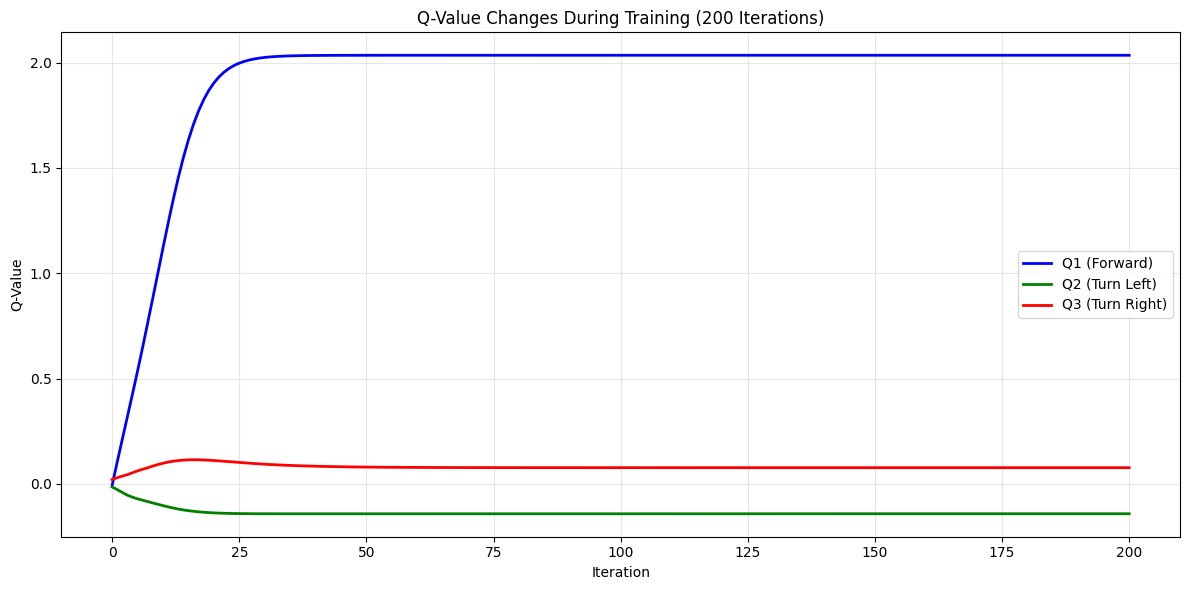


COMPARE Q-VALUES: INITIAL vs AFTER 200 ITERATIONS

Action          Initial Q       Final Q         Change         
-----------------------------------------------------------------
Forward         -0.0073         2.0344          ↑ 2.0417         
Turn Left       -0.0148         -0.1419         ↓ 0.1271         
Turn Right      0.0208          0.0768          ↑ 0.0560         
-----------------------------------------------------------------

Best Action Awal  : Turn Right
Best Action Akhir : Forward

Interpretasi: Setelah 200 iterasi, network telah mengupdate internal weights-nya
sehingga Q-values antar action tidak lagi seragam dan merefleksikan 'knowledge' dari reward.


In [459]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

ITERATION = 200  # variabel Anda - ubah sesuai keinginan

# Clear dan set title adaptif
display(Markdown(f"# Final Comparison: Initial vs {ITERATION}x Trained"))

# Inisialisasi Model Awal dengan seed random berdasarkan waktu
random_seed = 42893
torch.manual_seed(random_seed)
print(f"Using random seed for initialization: {random_seed}")

model_training = DQN(9, 3, 64)
optimizer = optim.SGD(model_training.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Data untuk Training
states = torch.FloatTensor([item[0] for item in MINI_BATCH])
targets_val = torch.FloatTensor(TARGET_VALUES)
actions = torch.LongTensor([item[1] for item in MINI_BATCH])

print(f"Memulai training {ITERATION} iterasi...")

# ========== LIST UNTUK MENYIMPAN Q-VALUES SETIAP ITERASI ==========
q1_history = []
q2_history = []
q3_history = []

# Simpan Q-values awal
with torch.no_grad():
    q_initial_tensor, _, _, _, _ = model_training(states[0:1])
    q_initial = q_initial_tensor.numpy().flatten()
    q1_history.append(q_initial[0])
    q2_history.append(q_initial[1])
    q3_history.append(q_initial[2])

# Variabel untuk menyimpan loss sebelumnya (untuk perhitungan persentase)
previous_loss = None

# Loop Training
for i in range(ITERATION):
    optimizer.zero_grad()
    all_q_values, _, _, _, _ = model_training(states)
    current_q = all_q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    loss = criterion(current_q, targets_val)
    loss.backward()
    optimizer.step()

    # ========== SIMPAN Q-VALUES SETIAP ITERASI ==========
    with torch.no_grad():
        q_tensor, _, _, _, _ = model_training(states[0:1])
        q = q_tensor.numpy().flatten()
        q1_history.append(q[0])
        q2_history.append(q[1])
        q3_history.append(q[2])

    # Print setiap 20 iterasi dengan persentase perubahan
    if (i + 1) % 20 == 0:
        current_loss = loss.item()
        if previous_loss is not None:
            change_percent = ((current_loss - previous_loss) / previous_loss) * 100
            if change_percent >= 0:
                print(f"Iteration {i+1}/{ITERATION} - Loss: {current_loss:.6f} (↑ {change_percent:.2f}% from before)")
            else:
                print(f"Iteration {i+1}/{ITERATION} - Loss: {current_loss:.6f} (↓ {abs(change_percent):.2f}% from before)")
        else:
            print(f"Iteration {i+1}/{ITERATION} - Loss: {current_loss:.6f}")
        previous_loss = current_loss

# Simpan Q-values akhir
with torch.no_grad():
    q_final_tensor, _, _, _, _ = model_training(states[0:1])
    q_final = q_final_tensor.numpy().flatten()

print(f"\n✓ Training {ITERATION} iterasi selesai.")

# ========== PLOT Q-VALUE CHANGES ==========
plt.figure(figsize=(12, 6))

iterations = range(ITERATION + 1)  # +1 karena include initial state

plt.plot(iterations, q1_history, 'b-', label='Q1 (Forward)', linewidth=2)
plt.plot(iterations, q2_history, 'g-', label='Q2 (Turn Left)', linewidth=2)
plt.plot(iterations, q3_history, 'r-', label='Q3 (Turn Right)', linewidth=2)

plt.xlabel('Iteration')
plt.ylabel('Q-Value')
plt.title(f'Q-Value Changes During Training ({ITERATION} Iterations)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== TABEL Q-VALUE COMPARISON ==========
print("\n" + "=" * 80)
print(f"COMPARE Q-VALUES: INITIAL vs AFTER {ITERATION} ITERATIONS")
print("=" * 80)

print(f"\n{'Action':<15} {'Initial Q':<15} {'Final Q':<15} {'Change':<15}")
print("-" * 65)

for i in range(3):
    diff = q_final[i] - q_initial[i]
    arrow = "↑" if diff > 0 else "↓"
    print(f"{action_names[i]:<15} {q_initial[i]:<15.4f} {q_final[i]:<15.4f} {arrow} {abs(diff):<15.4f}")

print("-" * 65)

best_initial = action_names[np.argmax(q_initial)]
best_final = action_names[np.argmax(q_final)]

print(f"\nBest Action Awal  : {best_initial}")
print(f"Best Action Akhir : {best_final}")
print(f"\nInterpretasi: Setelah {ITERATION} iterasi, network telah mengupdate internal weights-nya")
print(f"sehingga Q-values antar action tidak lagi seragam dan merefleksikan 'knowledge' dari reward.")